# Experiment C-1


C:\Users\dipan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Neural Network...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8308 - loss: 0.2706 
Neural Network Test Accuracy: 84.00%


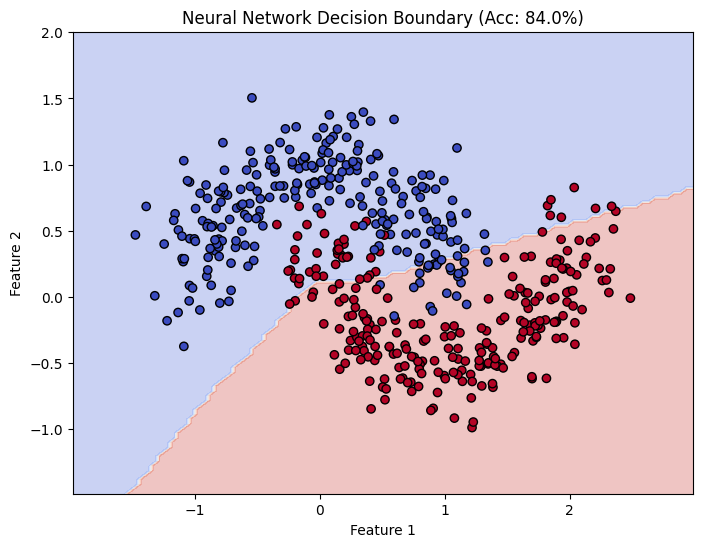

In [2]:
"""C-1: Train NN with TensorFlow/Keras for classification."""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Generate a toy dataset (Two Interleaving Moons)
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Build simple Neural Network
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train the model
print("Training Neural Network...")
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

# 4. Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=1)
print(f"Neural Network Test Accuracy: {acc * 100:.2f}%")

# 5. Plot Decision Boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predict for each point on the grid
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid, verbose=0)
Z = (Z > 0.5).astype(int).reshape(xx.shape)

# Plotting
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors='k')
plt.title(f"Neural Network Decision Boundary (Acc: {acc*100:.1f}%)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
